# Visual Analytics for Trustworthy GeoAI

## Introduction & Setup 🚀

Welcome! This is the starting point for the **Spatial Visual Analytics for
Trustworthy GeoAI** practicals. This short notebook will:

1. set up everything you need (works on **Google Colab** with no local install),
2. download the course data and the small `geocp` package, and
3. run a quick check so you know your environment is ready.

Once this notebook runs end-to-end, the case studies will work too.

### The case studies

| | Notebook | Topic |
|---|---|---|
| **Case 1** | [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Vezarachan/TUM_Course_SVA_TrustGeoAI/blob/main/notebooks/TrustworthyGeoAI_case_1.ipynb) | Uncertainty in spatial **data** |
| **Case 2** | [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Vezarachan/TUM_Course_SVA_TrustGeoAI/blob/main/notebooks/TrustworthyGeoAI_case_2.ipynb) | Uncertainty in spatially explicit **modeling** |

### How to use this on Google Colab

1. Click an **Open in Colab** badge above (or open this notebook from
   `colab.research.google.com` → GitHub → search `TUM_Course_SVA_TrustGeoAI`).
2. Run the cells top to bottom with **Shift + Enter**, or
   *Runtime → Run all*.
3. The first setup cell installs a few geospatial packages and takes **1–2
   minutes** the first time — this is normal. You do **not** need a GPU.

Everything below also runs on a normal local Python environment.

### Step 1 — Install the packages

In [1]:
# On Colab this installs the geospatial stack (1-2 min the first time).
# On a machine that already has these, it does nothing.
import importlib, subprocess, sys

IMPORT_NAME = {"scikit-learn": "sklearn"}   # pip name -> import name

def ensure(pkgs):
    missing = [p for p in pkgs
               if importlib.util.find_spec(IMPORT_NAME.get(p.split("==")[0], p.split("==")[0])) is None]
    if missing:
        print("installing:", ", ".join(missing), "...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
    print("✅ packages ready")

ensure(["geopandas", "mgwr", "libpysal", "esda", "scikit-learn", "xgboost"])

✅ packages ready


### Step 2 — Download the data and the `geocp` package

In [2]:
# Downloads the files the case studies need from the course GitHub repo, into a
# local data/ and geocp/ folder. Safe to re-run (it skips files already present).
import os, urllib.request

REPO, BRANCH = "Vezarachan/TUM_Course_SVA_TrustGeoAI", "main"
FILES = [
    "data/seattle_sample_3k.csv",
    "data/king_county.gpkg",
    "data/US_Climate_ERA5_CLIMATE.csv",
] + [f"geocp/{f}" for f in
     ["__init__.py", "core.py", "estimators.py", "results.py", "utils.py", "weights.py"]]

for path in FILES:
    if not os.path.exists(path):
        os.makedirs(os.path.dirname(path), exist_ok=True)
        urllib.request.urlretrieve(f"https://raw.githubusercontent.com/{REPO}/{BRANCH}/{path}", path)
        print("downloaded", path)
    else:
        print("cached    ", path)
print("\n✅ data and geocp ready")

cached     data/seattle_sample_3k.csv
cached     data/king_county.gpkg
cached     data/US_Climate_ERA5_CLIMATE.csv
cached     geocp/__init__.py
cached     geocp/core.py
cached     geocp/estimators.py
cached     geocp/results.py
cached     geocp/utils.py
cached     geocp/weights.py

✅ data and geocp ready


### Step 3 — Check that everything works

In [3]:
# Imports + versions. If this cell runs without errors, your environment is good.
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib, sklearn, xgboost, mgwr, libpysal, esda
import geocp

for name, mod in [("numpy", np), ("pandas", pd), ("geopandas", gpd),
                  ("matplotlib", matplotlib), ("scikit-learn", sklearn),
                  ("xgboost", xgboost), ("mgwr", mgwr), ("geocp", geocp)]:
    print(f"  {name:14s} {getattr(mod, '__version__', '?')}")
print("\n✅ all imports succeeded")

  numpy          2.4.2
  pandas         3.0.2
  geopandas      1.1.3
  matplotlib     3.10.8
  scikit-learn   1.8.0
  xgboost        3.2.0
  mgwr           2.2.1
  geocp          0.1.0

✅ all imports succeeded


C:\Users\Xiayin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


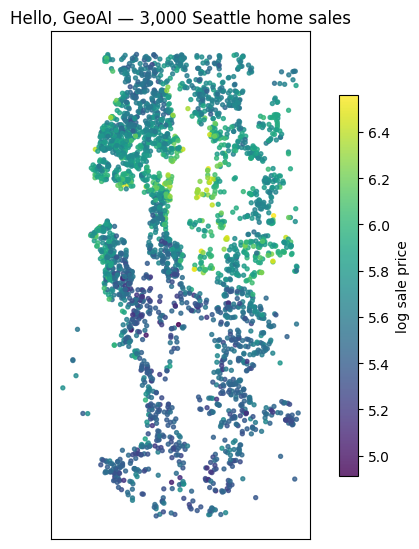

In [4]:
# A first map: the Seattle home-sale sample used in Case 2.
import matplotlib.pyplot as plt
df = pd.read_csv("data/seattle_sample_3k.csv")
fig, ax = plt.subplots(figsize=(6.2, 5.6))
sc = ax.scatter(df["UTM_X"], df["UTM_Y"], c=df["log_price"], cmap="viridis", s=8, alpha=0.8)
plt.colorbar(sc, ax=ax, shrink=0.75, label="log sale price")
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
ax.set_title("Hello, GeoAI — 3,000 Seattle home sales")
plt.tight_layout(); plt.show()

In [5]:
# A tiny GeoConformal Prediction demo: 90% prediction intervals for a toy model.
from geocp import GeoConformalPrediction
from geocp.weights import uniform_weights

rng = np.random.default_rng(0)
n = 400
x = rng.uniform(0, 10, n)
y = 2*x + rng.normal(0, 1.5, n)          # noisy linear data
slope = np.polyfit(x[:200], y[:200], 1)  # "fit" on the first half
predict = lambda xx: np.polyval(slope, np.asarray(xx).ravel())

cp = GeoConformalPrediction(predict, x[200:300, None], y[200:300],
                            uniform_weights(), miscoverage_level=0.10)
res = cp.conformalize(x[300:, None], y[300:])
print(f"target coverage 90%  ->  empirical coverage = {res.coverage:.0%}, "
      f"interval width = {res.mean_width_finite:.2f}")
print("✅ geocp works — you're ready for the case studies!")

target coverage 90%  ->  empirical coverage = 89%, interval width = 5.12
✅ geocp works — you're ready for the case studies!


### You're set 🎉

If every cell above ran without errors, your environment is ready. Continue to:

* **Case 1 — Uncertainty in spatial data** &nbsp;
  [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Vezarachan/TUM_Course_SVA_TrustGeoAI/blob/main/notebooks/TrustworthyGeoAI_case_1.ipynb)
* **Case 2 — Uncertainty in spatially explicit modeling** &nbsp;
  [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Vezarachan/TUM_Course_SVA_TrustGeoAI/blob/main/notebooks/TrustworthyGeoAI_case_2.ipynb)

### What's in the `data/` folder

| File | What it is | Used in |
|---|---|---|
| `seattle_sample_3k.csv` | 3,000 Seattle home sales (price, features, location) | Case 2 |
| `king_county.gpkg` | King County boundary (basemap) | Case 2 |
| `US_Climate_ERA5_CLIMATE.csv` | a continuous target + predictors across US climate regions | Case 2 |
| `eurosat_metadata.parquet`, city building footprints, … | spatial-data examples | Case 1 |

**Tip:** if a download cell ever fails on Colab, just re-run it — it only fetches
files that are missing.